In [1]:
# REPLACE your Cell A with this
import warnings
warnings.filterwarnings("ignore")

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import torch

import ray
from ray.rllib.algorithms.ppo import PPOConfig
from ray.tune.registry import register_env

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

try:
    ray.shutdown()
except Exception:
    pass

2026-06-24 17:40:29,519	WARNING compression.py:17 -- lz4 not available, disabling sample compression. This will significantly impact RLlib performance. To install lz4, run `pip install lz4`.


In [2]:
# Cell B: load data + clean accidental extra column
df = pd.read_excel("category_inventory_sim.xlsx").reset_index(drop=True)

# remove noisy unnamed columns if present
unnamed_cols = [c for c in df.columns if str(c).startswith("Unnamed")]
if unnamed_cols:
    df = df.drop(columns=unnamed_cols)

print(df.shape)
df.head()

(900, 17)


,sector,year,month,week_of_month,t_step,demand,fulfilled_demand,lost_sales,on_hand_inventory,on_order_inventory,inventory_position,order_qty,leadtime_steps,ROP,target_level,holding_cost,reward
0,اثاث,2022,4,1,12,38.249195,38.249195,0.0,24.168112,66.641135,90.809247,69.169692,3,114.854740,253.194124,24.168112,-24.168112
1,اثاث,2022,4,2,13,34.664382,34.664382,0.0,56.144865,69.169692,125.314557,0.000000,3,114.889379,256.621312,56.144865,-56.144865
2,اثاث,2022,4,3,14,28.440053,28.440053,0.0,96.874504,0.000000,96.874504,70.275476,3,114.892688,255.443641,96.874504,-96.874504
3,اثاث,2022,4,4,15,34.157468,34.157468,0.0,62.717036,70.275476,132.992512,0.000000,3,115.107650,256.076770,62.717036,-62.717036
4,اثاث,2022,5,1,16,32.644441,32.644441,0.0,30.072595,70.275476,100.348071,71.029612,3,115.217944,257.277168,30.072595,-30.072595


In [3]:
print(df.columns.tolist())

['sector', 'year', 'month', 'week_of_month', 't_step', 'demand', 'fulfilled_demand', 'lost_sales', 'on_hand_inventory', 'on_order_inventory', 'inventory_position', 'order_qty', 'leadtime_steps', 'ROP', 'target_level', 'holding_cost', 'reward']


In [4]:
# Cell B2 — category_inventory_sim.xlsx preprocessor
import copy
import pandas as pd
import numpy as np

# ── 1. اقرأ الداتا ──────────────────────────────────────────────────────────
df_raw = pd.read_excel("category_inventory_sim.xlsx")

# ازل الـ unnamed columns لو موجودة
unnamed_cols = [c for c in df_raw.columns if str(c).startswith("Unnamed")]
if unnamed_cols:
    df_raw = df_raw.drop(columns=unnamed_cols)

# ── 2. الـ column mapping ─────────────────────────────────────────────────────
df = pd.DataFrame()

df["demand"]             = df_raw["demand"].astype(float)
df["on_hand_inventory"]  = df_raw["on_hand_inventory"].astype(float)
df["on_order_inventory"] = df_raw["on_order_inventory"].astype(float)
df["inventory_position"] = df_raw["inventory_position"].astype(float)
df["leadtime_steps"]     = df_raw["leadtime_steps"].astype(float)
df["month"]              = df_raw["month"].astype(float)
df["ReorderLevel"]       = df_raw["ROP"].astype(float)   # ROP = Reorder Point
df["order_qty"] = pd.to_numeric(
    df_raw["order_qty"],
    errors="coerce"
).fillna(0)


# ── 3. احسب الـ reward بنفس منطق الـ env ──────────────────────────────────
ORDER_COST     = 0.5
HOLDING_COST   = 0.2
LOST_SALES_PEN = 5.0
SELLING_PRICE  = 10.0

fulfilled  = np.minimum(df["demand"], df["on_hand_inventory"])
lost_sales = (df["demand"] - fulfilled).clip(lower=0)

df["fulfilled"]          = fulfilled
df["lost_sales"]         = lost_sales
df["revenue"]            = fulfilled * SELLING_PRICE
df["holding_penalty"]    = df["on_hand_inventory"] * HOLDING_COST
df["ordering_penalty"]   = df["on_order_inventory"] * ORDER_COST
df["lost_sales_penalty"] = lost_sales * LOST_SALES_PEN

df["reward"]         = (
      df["revenue"]
    - df["holding_penalty"]
    - df["ordering_penalty"]
    - df["lost_sales_penalty"]
)
df["reward_clipped"] = df["reward"].clip(-200, 200)

# ── 4. رتّب بالـ t_step (الداتا مرتبة بالفعل، بس احتياطاً) ──────────────────
df.insert(0, "t_step", df_raw["t_step"].values)
df.insert(1, "sector", df_raw["sector"].values)
df = df.sort_values("t_step").reset_index(drop=True)

# ── 5. تحقق سريع ─────────────────────────────────────────────────────────────
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nNull check:\n", df.isnull().sum())
print("\nStats:\n", df.describe().round(2))
print(f"\nreward sum (raw)    : {df['reward'].sum():.4f}")
print(f"reward sum (clipped): {df['reward_clipped'].sum():.4f}")

# ── 6. reward breakdown display ───────────────────────────────────────────────
reward_cols = [
    "t_step", "sector", "demand", "fulfilled", "lost_sales",
    "on_hand_inventory", "on_order_inventory",
    "revenue", "holding_penalty", "ordering_penalty", "lost_sales_penalty",
    "reward", "reward_clipped"
]
display(df[reward_cols].head(10))

Shape: (900, 18)

Columns: ['t_step', 'sector', 'demand', 'on_hand_inventory', 'on_order_inventory', 'inventory_position', 'leadtime_steps', 'month', 'ReorderLevel', 'order_qty', 'fulfilled', 'lost_sales', 'revenue', 'holding_penalty', 'ordering_penalty', 'lost_sales_penalty', 'reward', 'reward_clipped']

Null check:
 t_step                0
sector                0
demand                0
on_hand_inventory     0
on_order_inventory    0
inventory_position    0
leadtime_steps        0
month                 0
ReorderLevel          0
order_qty             0
fulfilled             0
lost_sales            0
revenue               0
holding_penalty       0
ordering_penalty      0
lost_sales_penalty    0
reward                0
reward_clipped        0
dtype: int64

Stats:
        t_step  demand  on_hand_inventory  on_order_inventory  \
count  900.00  900.00             900.00              900.00   
mean   101.50   68.06              76.84              149.37   
std     51.99  109.99             

,t_step,sector,demand,fulfilled,lost_sales,on_hand_inventory,on_order_inventory,revenue,holding_penalty,ordering_penalty,lost_sales_penalty,reward,reward_clipped
0,12,اثاث,38.249195,24.168112,14.081083,24.168112,66.641135,241.681119,4.833622,33.320567,70.405416,133.121513,133.121513
1,12,مفروشات,1.169051,1.028613,0.140438,1.028613,1.739563,10.286126,0.205723,0.869781,0.702191,8.508431,8.508431
2,12,مواد البناء,229.233503,229.233503,0.000000,440.343722,0.000000,2292.335027,88.068744,0.000000,0.000000,2204.266282,200.000000
3,12,جلود و احذية و منتجات جلدية,3.654541,3.654541,0.000000,10.300610,0.000000,36.545406,2.060122,0.000000,0.000000,34.485284,34.485284
4,12,الطباعة والتغليف والورق والكتب والمصنفات الفنية,45.333827,45.333827,0.000000,48.171436,77.048830,453.338267,9.634287,38.524415,0.000000,405.179565,200.000000
5,13,اثاث,34.664382,34.664382,0.000000,56.144865,69.169692,346.643820,11.228973,34.584846,0.000000,300.830001,200.000000
6,13,مواد البناء,182.004908,182.004908,0.000000,258.338814,334.560508,1820.049083,51.667763,167.280254,0.000000,1601.101067,200.000000
7,13,مفروشات,0.821906,0.206706,0.615200,0.206706,3.498787,2.067063,0.041341,1.749394,3.076000,-2.799672,-2.799672
8,13,جلود و احذية و منتجات جلدية,2.859485,2.859485,0.000000,7.441125,6.583811,28.594850,1.488225,3.291906,0.000000,23.814720,23.814720
9,13,الطباعة والتغليف والورق والكتب والمصنفات الفنية,48.217079,48.217079,0.000000,79.199562,77.048830,482.170791,15.839912,38.524415,0.000000,427.806464,200.000000


In [5]:
print(df["order_qty"].describe())
print(df["order_qty"].head())

count    900.000000
mean      63.104721
std      157.571247
min        0.000000
25%        0.000000
50%        0.000000
75%       72.482557
max      982.903484
Name: order_qty, dtype: float64
0     69.169692
1      1.759225
2    334.560508
3      6.583811
4     79.245205
Name: order_qty, dtype: float64


In [6]:
class SupplyChainEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, config):
        super().__init__()
        self.data = config["data"].reset_index(drop=True)
        self.max_steps = len(self.data)

        self.n_bins    = int(config.get("n_bins", 20))
        self.max_order = int(config.get("max_order", 200))
        self.bin_size  = self.max_order / self.n_bins

        self.selling_price      = float(config.get("selling_price", 10.0))
        self.order_cost         = float(config.get("order_cost", 0.5))
        self.holding_cost_rate  = float(config.get("holding_cost_rate", 0.2))
        self.lost_sales_penalty = float(config.get("lost_sales_penalty", 5.0))
        self.reward_clip        = float(config.get("reward_clip", 200.0))  # ← 500 → 200
        self.use_clipped_reward = bool(config.get("use_clipped_reward", True))

        self.current_step = 0
        self.on_hand = 0.0

        self.action_space      = spaces.Discrete(self.n_bins)
        self.observation_space = spaces.Box(low=-10, high=10, shape=(6,), dtype=np.float32)

        cols = ["demand", "on_hand_inventory", "on_order_inventory",
                "inventory_position", "leadtime_steps", "month"]
        arr = self.data[cols].astype(float).values
        self.obs_mean = arr.mean(axis=0)
        self.obs_std  = arr.std(axis=0) + 1e-6

    def _norm_obs(self, raw):
        z = (raw - self.obs_mean) / self.obs_std
        return np.clip(z, -10, 10).astype(np.float32)

    def _get_obs(self, row):
        raw = np.array([
            float(row["demand"]),
            float(self.on_hand),
            float(row["on_order_inventory"]),
            float(row["inventory_position"]),
            float(row["leadtime_steps"]),
            float(row["month"]),
        ], dtype=np.float32)
        return self._norm_obs(raw)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:                   # ← added
            np.random.seed(seed)               # ← added

        self.current_step = 0
        first = self.data.iloc[0]
        self.on_hand = float(first["on_hand_inventory"])
        return self._get_obs(first), {}

    def step(self, action):
        row = self.data.iloc[self.current_step]

        demand    = float(row["demand"])
        order_qty = float(int(action)) * self.bin_size

        # ======================
        # SELL FIRST (realistic)  ← fixed: was on_hand + order_qty
        # ======================
        available   = self.on_hand
        fulfilled   = min(demand, available)
        lost_sales  = max(demand - fulfilled, 0.0)
        end_on_hand = max(available - fulfilled, 0.0)

        # ======================
        # ORDER ARRIVES
        # ======================
        end_on_hand += order_qty

        # ======================
        # COSTS
        # ======================
        revenue  = fulfilled * self.selling_price
        holding  = end_on_hand * self.holding_cost_rate
        ordering = order_qty * self.order_cost
        lost     = lost_sales * self.lost_sales_penalty

        # ======================
        # REORDER LOGIC          ← added
        # ======================
        reorder_level = float(row.get("ReorderLevel", 0))

        early_order_penalty = 0.0
        no_order_penalty    = 0.0

        if order_qty > 0 and self.on_hand > reorder_level:
            early_order_penalty = 5.0

        if order_qty == 0 and self.on_hand < reorder_level:
            no_order_penalty = 5.0

        # ======================
        # FINAL REWARD
        # ======================
        raw_reward = (
            revenue
            - holding
            - ordering
            - lost
            - early_order_penalty
            - no_order_penalty
        )

        if np.isnan(raw_reward):               # ← added
            raw_reward = -100.0                # ← added

        clipped_reward = float(np.clip(raw_reward, -self.reward_clip, self.reward_clip))
        reward         = clipped_reward if self.use_clipped_reward else float(raw_reward)

        # ======================
        # UPDATE STATE
        # ======================
        self.on_hand      = end_on_hand
        self.current_step += 1

        terminated = self.current_step >= (self.max_steps - 1)
        truncated  = False
        next_row   = self.data.iloc[self.current_step] if not terminated else row
        obs        = self._get_obs(next_row)

        info = {
            "raw_reward":          float(raw_reward),
            "clipped_reward":      float(clipped_reward),
            "fulfilled":           fulfilled,
            "lost_sales":          lost_sales,
            "end_on_hand":         end_on_hand,
            "early_order_penalty": early_order_penalty,  # ← added
            "no_order_penalty":    no_order_penalty,     # ← added
        }
        return obs, reward, terminated, truncated, info

In [7]:
# REPLACE your Cell D with this (strict clean init)

ENV_NAME = "SupplyChainEnv-v0"

def env_creator(config):
    return SupplyChainEnv(config)

try:
    ray.shutdown()
except:
    pass

ray.init(ignore_reinit_error=False, include_dashboard=False,
         log_to_driver=False, num_cpus=2)
register_env(ENV_NAME, env_creator)
print("Ray initialized cleanly")

2026-06-24 17:40:42,652	INFO worker.py:2013 -- Started a local Ray instance.


Ray initialized cleanly


In [8]:
env_config = {
    "data": df,
    "max_order": 120,
    "selling_price": 10.0,       # was missing effective revenue
    "order_cost": 0.5,
    "holding_cost_rate": 0.2,
    "lost_sales_penalty": 60.0,  # was 5 — not painful enough
    "reward_clip": 5000.0,        # tighter than 1000
    "use_clipped_reward": False,
}

config = (
    PPOConfig()
    .environment(env=ENV_NAME, env_config=env_config)
    .framework("torch")
    .debugging(seed=SEED)
    .env_runners(num_env_runners=2)   # more parallelism
    .training(
        lr=3e-5,              # was 1e-5 — too slow to converge
        gamma=0.99,
        lambda_=0.95,
        clip_param=0.2,
        entropy_coeff=0.01,   # was 0.1 — too much exploration, hurts exploitation
        vf_loss_coeff=0.5,
        train_batch_size=8192, # larger = more stable gradients
        minibatch_size=512,
        num_epochs=10,         # more SGD passes per batch
        grad_clip=0.5,
    )
)
algo = config.build_algo()
print("PPO built successfully (seeded)")

2026-06-24 17:40:43,556	WARNING algorithm_config.py:5131 -- You are running PPO on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
d:\Study\GradProject\Backup Data\Grad Projectv1\RL\.conda\Lib\site-packages\ray\rllib\algorithms\algorithm.py:527: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  return UnifiedLogger(config, logdir, loggers=None)
d:\Study\GradProject\Backup Data\Grad Projectv1\RL\.conda\Lib\site-packages\ray\tune\logger\unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray 

PPO built successfully (seeded)


In [9]:
# Cell F: train
num_iters = 500
results = []
rl_train_rewards = []

for i in range(num_iters):
    r = algo.train()
    results.append(r)

    rew = r.get("env_runners", {}).get("episode_return_mean", None)
    if rew is None:
        rew = r.get("episode_reward_mean", np.nan)

    rl_train_rewards.append(float(rew))
    print(f"Iter {i+1:02d} | train mean reward = {rew:.4f}")

Iter 01 | train mean reward = -356241.4723
Iter 02 | train mean reward = -352088.4067
Iter 03 | train mean reward = -337297.8139
Iter 04 | train mean reward = -306242.3533
Iter 05 | train mean reward = -293290.0821
Iter 06 | train mean reward = -310225.3517
Iter 07 | train mean reward = -297249.4050
Iter 08 | train mean reward = -248915.5400
Iter 09 | train mean reward = -212502.6460
Iter 10 | train mean reward = -223999.5989
Iter 11 | train mean reward = -175777.5050
Iter 12 | train mean reward = -173486.3539
Iter 13 | train mean reward = -94646.4758
Iter 14 | train mean reward = -83619.1628
Iter 15 | train mean reward = -31434.2558
Iter 16 | train mean reward = 11366.0962
Iter 17 | train mean reward = 50436.3268
Iter 18 | train mean reward = 77546.6544
Iter 19 | train mean reward = 100606.2750
Iter 20 | train mean reward = 143245.5762
Iter 21 | train mean reward = 180719.3987
Iter 22 | train mean reward = 196993.7792
Iter 23 | train mean reward = 237491.4404
Iter 24 | train mean rewa

In [10]:
import os

# get absolute path
save_path = os.path.abspath("rl_inventory_model")
algo.save(save_path)
print(f"Model saved to: {save_path}")

Model saved to: d:\github\Grad.app\rl_inventory_model


In [11]:
# Cell — Export model + normalization stats for Streamlit

import json
import numpy as np

# Save the normalization stats the env computed
env_temp = SupplyChainEnv(env_config)

norm_stats = {
    "obs_mean": env_temp.obs_mean.tolist(),
    "obs_std": env_temp.obs_std.tolist(),
    "max_order": env_config["max_order"],
    "selling_price": 10.0,
    "order_cost": env_config["order_cost"],
    "holding_cost_rate": env_config["holding_cost_rate"],
    "lost_sales_penalty": env_config["lost_sales_penalty"],
}

with open("model_config.json", "w") as f:
    json.dump(norm_stats, f, indent=2)

print("Saved model_config.json")
print("obs_mean:", norm_stats["obs_mean"])
print("obs_std:", norm_stats["obs_std"])

Saved model_config.json
obs_mean: [68.05674094283998, 76.8436653482949, 149.37228842755474, 226.21595377584964, 3.2, 6.8]
obs_std: [109.93015361507236, 158.19479126016427, 281.9076971720258, 361.02443154871986, 0.40000099999999994, 3.350622832834417]


In [12]:
# REPLACE your Cell G with this (multi-episode deterministic eval)

def evaluate_algo_deterministic(algo, env, max_steps=10000):
    obs, _ = env.reset(seed=SEED)
    total_reward = 0.0
    steps = 0

    module = algo.get_module("default_policy")

    while True:
        batch_obs = torch.as_tensor(np.expand_dims(obs, axis=0), dtype=torch.float32)
        with torch.no_grad():
            out = module.forward_inference({"obs": batch_obs})

        if "actions" in out:
            a = out["actions"]
            action = int(a.squeeze().item()) if isinstance(a, torch.Tensor) else int(np.asarray(a).squeeze())
        elif "action_dist_inputs" in out:
            logits = out["action_dist_inputs"]
            if not isinstance(logits, torch.Tensor):
                logits = torch.as_tensor(logits, dtype=torch.float32)
            action = int(torch.argmax(logits, dim=-1).squeeze().item())  # greedy deterministic
        else:
            raise KeyError(f"Unexpected output keys: {list(out.keys())}")

        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += float(reward)
        steps += 1

        if terminated or truncated or steps >= max_steps:
            break

    return total_reward, steps


def evaluate_n_episodes(algo, env_config, n=10):
    vals = []
    for _ in range(n):
        e = SupplyChainEnv(env_config)
        r, _ = evaluate_algo_deterministic(algo, e)
        vals.append(r)
    vals = np.array(vals, dtype=float)
    return vals.mean(), vals.std(), vals

eval_mean, eval_std, eval_vals = evaluate_n_episodes(algo, env_config, n=10)
print(f"RL eval mean (deterministic, {len(eval_vals)} eps): {eval_mean:.4f} ± {eval_std:.4f}")

RL eval mean (deterministic, 10 eps): 398758.6829 ± 0.0000


In [13]:
def compute_baseline_reward(df):
    rewards = []

    on_hand = 0

    for _, row in df.iterrows():
        demand = float(row["UnitsSold"])
        stock = float(row["StockQuantity"])
        reorder_qty = float(row.get("ReorderQuantity", 0))
        reorder_level = float(row.get("ReorderLevel", 0))
        price = float(row.get("UnitPrice", 10))

        # simulate Zepto behavior
        available = stock
        fulfilled = min(demand, available)
        lost_sales = max(demand - fulfilled, 0)
        end_on_hand = max(available - fulfilled, 0)

        # reorder rule
        if stock <= reorder_level:
            end_on_hand += reorder_qty
            ordering = reorder_qty * 0.5
        else:
            ordering = 0

        revenue = fulfilled * price
        holding = end_on_hand * 0.2
        lost = lost_sales * 5

        reward = revenue - holding - ordering - lost
        rewards.append(reward)

    return np.array(rewards)

In [14]:
# REPLACE your Cell H with this
# (and DELETE old cells 9 and 10 to avoid contradictory tables)

baseline_raw = float(df["reward"].sum())
baseline_clipped = float(np.clip(df["reward"].values, -env_config["reward_clip"], env_config["reward_clip"]).sum())

print(f"Baseline raw reward     : {baseline_raw:.4f}")
print(f"Baseline clipped reward : {baseline_clipped:.4f}")

# Fair comparison: clipped RL vs clipped baseline (because training/eval env uses clipped reward)
improvement_abs = eval_mean - baseline_clipped
improvement_pct = (improvement_abs / (abs(baseline_clipped) + 1e-9)) * 100

comparison = pd.DataFrame({
    "metric": [
        "Baseline (raw)",
        "Baseline (clipped)",
        "RL eval mean (deterministic, 10 eps)",
        "RL eval std",
        "Absolute Improvement vs clipped baseline",
        "Improvement % vs clipped baseline"
    ],
    "value": [baseline_raw, baseline_clipped, eval_mean, eval_std, improvement_abs, improvement_pct]
})
comparison

Baseline raw reward     : 204961.0040
Baseline clipped reward : 204961.0040


,metric,value
0,Baseline (raw),2.049610e+05
1,Baseline (clipped),2.049610e+05
2,"RL eval mean (deterministic, 10 eps)",3.987587e+05
3,RL eval std,5.820766e-11
4,Absolute Improvement vs clipped baseline,1.937977e+05
5,Improvement % vs clipped baseline,9.455344e+01


In [20]:
print("baseline_clipped =", baseline_clipped)

baseline_clipped = 204961.00400590556


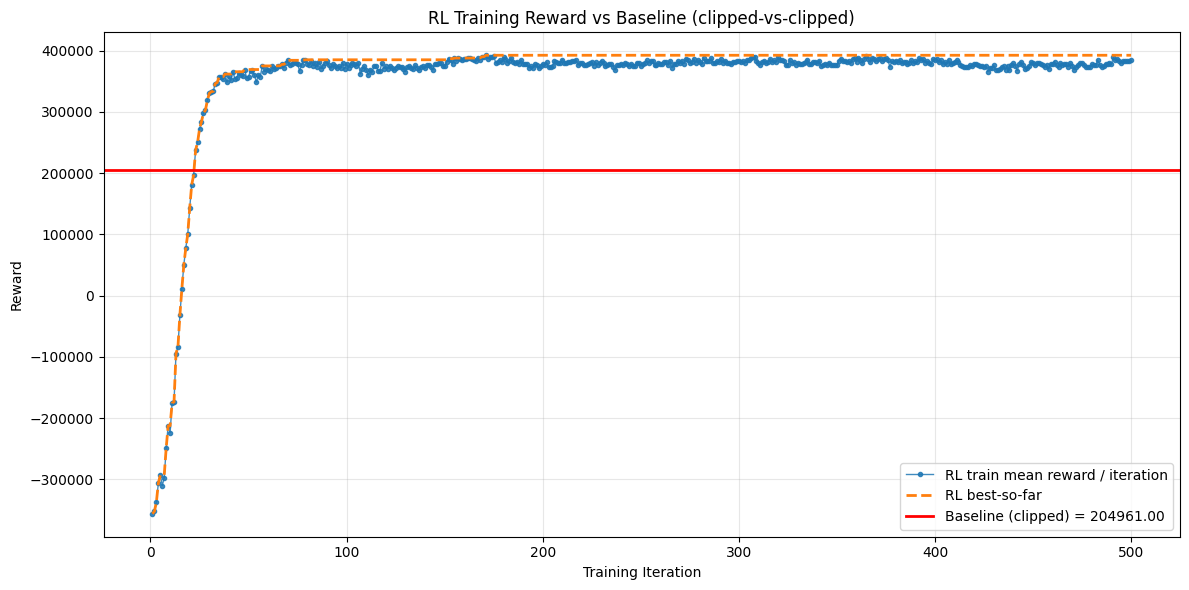

In [15]:
# REPLACE your Cell I with this

rl_train_rewards = np.array(rl_train_rewards, dtype=float)
x = np.arange(1, len(rl_train_rewards) + 1)
best_so_far = np.maximum.accumulate(np.nan_to_num(rl_train_rewards, nan=-np.inf))

plt.figure(figsize=(12,6))
plt.plot(x, rl_train_rewards, marker='o', ms=3, lw=1, alpha=0.85, label="RL train mean reward / iteration")
plt.plot(x, best_so_far, '--', lw=2, label="RL best-so-far")
plt.axhline(y=baseline_clipped, color='red', lw=2, label=f"Baseline (clipped) = {baseline_clipped:.2f}")
plt.title("RL Training Reward vs Baseline (clipped-vs-clipped)")
plt.xlabel("Training Iteration")
plt.ylabel("Reward")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# Cell G2 — KPI evaluation
def get_deterministic_action_from_algo(algo, obs):
    module = algo.get_module("default_policy")
    batch_obs = torch.as_tensor(np.expand_dims(obs, axis=0), dtype=torch.float32)
    with torch.no_grad():
        out = module.forward_inference({"obs": batch_obs})

    if "actions" in out:
        a = out["actions"]
        action = int(a.squeeze().item()) if isinstance(a, torch.Tensor) else int(np.asarray(a).squeeze())
    elif "action_dist_inputs" in out:
        logits = out["action_dist_inputs"]
        if not isinstance(logits, torch.Tensor):
            logits = torch.as_tensor(logits, dtype=torch.float32)
        action = int(torch.argmax(logits, dim=-1).squeeze().item())
    else:
        raise KeyError(f"Unexpected output keys: {list(out.keys())}")
    return action
def run_episode_with_policy(env_config, policy_fn, seed=SEED):
    env = SupplyChainEnv(env_config)
    obs, _ = env.reset(seed=seed)

    rows = []
    while True:
        action = policy_fn(obs, env)
        obs, reward, terminated, truncated, info = env.step(action)
        rows.append({
            "demand":         info.get("fulfilled", 0) + info.get("lost_sales", 0),
            "fulfilled":      info.get("fulfilled", 0),
            "lost_sales":     info.get("lost_sales", 0),
            "end_on_hand":    info.get("end_on_hand", 0),
            "order_qty":      action,
            "reward_env":     reward,
            "raw_reward":     info.get("raw_reward", reward),
        })
        if terminated or truncated:
            break
    return pd.DataFrame(rows)

def summarize_kpis(ep_df):
    total_demand   = ep_df["demand"].sum()
    total_fulfilled = ep_df["fulfilled"].sum()
    return {
        "fill_rate":       round(total_fulfilled / (total_demand + 1e-9), 4),
        "total_lost_sales": round(ep_df["lost_sales"].sum(), 2),
        "avg_end_on_hand":  round(ep_df["end_on_hand"].mean(), 2),
        "avg_order_qty":    round(ep_df["order_qty"].mean(), 2),
        "sum_reward_env":   round(ep_df["reward_env"].sum(), 2),
        "sum_reward_raw":   round(ep_df["raw_reward"].sum(), 2),
    }

# RL policy
def rl_policy_fn(obs, env):
    return get_deterministic_action_from_algo(algo, obs)

# Baseline policy — order ReorderQuantity when below ReorderLevel
def baseline_policy_fn(obs, env):
    step = min(env.current_step, len(env.data) - 1)
    row = env.data.iloc[step]
    if env.on_hand <= float(row.get("ReorderLevel", row.get("on_hand_inventory", 0))):
        return int(row.get("ReorderQuantity", row.get("on_order_inventory", 0)))
    return 0

# Run both
rl_ep  = run_episode_with_policy(env_config, rl_policy_fn)
bl_ep  = run_episode_with_policy(env_config, baseline_policy_fn)

rl_kpi = summarize_kpis(rl_ep)
bl_kpi = summarize_kpis(bl_ep)

kpi_table = pd.DataFrame([
    {"policy": "Baseline", **bl_kpi},
    {"policy": "RL",       **rl_kpi},
])

display(kpi_table)

,policy,fill_rate,total_lost_sales,avg_end_on_hand,avg_order_qty,sum_reward_env,sum_reward_raw
0,Baseline,0.9908,563.13,2595.23,11.58,74850.09,74850.09
1,RL,0.9861,851.93,662.90,11.28,398758.68,398758.68


,best_train_iter,best_train_reward
0,171,392442.654153


,policy,steps,total_demand,total_fulfilled,fill_rate,total_lost_sales,avg_lost_sales_per_step,avg_end_on_hand,sum_reward_env,sum_reward_raw,sum_reward_clipped,avg_order_qty,sum_order_qty
0,Baseline,899,61215.843549,61201.762465,0.999770,14.081083,0.015663,49451.588522,-8.357581e+06,-8.357581e+06,-3.823668e+06,27.893215,25076.0
1,RL,899,61215.843549,60363.918414,0.986083,851.925134,0.947636,662.897626,3.987587e+05,3.987587e+05,4.096068e+05,11.281424,10142.0


,metric,rl_minus_baseline
0,fill_rate,-1.368672e-02
1,total_lost_sales,8.378441e+02
2,avg_end_on_hand,-4.878869e+04
3,sum_reward_env,8.756340e+06
4,sum_reward_raw,8.756340e+06
5,sum_reward_clipped,4.233275e+06
6,avg_order_qty,-1.661179e+01


,step_idx,t_step,month,demand,rl_order_qty,reward_env,reward_raw,reward_clipped,fulfilled,lost_sales,end_on_hand,baseline_order_qty,delta_order_qty_rl_minus_baseline,baseline_lost_sales,delta_lost_sales_rl_minus_baseline,baseline_reward_env,delta_reward_env_rl_minus_baseline
0,0,12,4,38.249195,19,-682.983874,-682.983874,-682.983874,24.168112,14.081083,114.000000,69,-50,14.081083,0.000000,-892.983874,210.000000
1,1,12,4,1.169051,19,-95.675683,-95.675683,-95.675683,1.169051,0.000000,226.830949,2,17,0.000000,0.000000,-84.275683,-11.400000
2,2,12,4,229.233503,19,2044.356288,2044.356288,2044.356288,226.830949,2.402553,114.000000,119,-100,0.000000,2.402553,1753.415537,290.940751
3,3,12,4,3.654541,19,-70.323685,-70.323685,-70.323685,3.654541,0.000000,224.345459,7,12,0.000000,0.000000,-179.043175,108.719489
4,4,12,4,45.333827,19,332.735941,332.735941,332.735941,45.333827,0.000000,293.011633,79,-60,0.000000,0.000000,-63.983549,396.719489
5,5,13,4,34.664382,19,210.174370,210.174370,210.174370,34.664382,0.000000,372.347251,0,19,0.000000,0.000000,78.254880,131.919489
6,6,13,4,182.004908,19,1702.180615,1702.180615,1702.180615,182.004908,0.000000,304.342342,0,19,0.000000,0.000000,1588.061125,114.119489
7,7,13,4,0.821906,19,-137.285024,-137.285024,-137.285024,0.821906,0.000000,417.520436,0,19,0.000000,0.000000,-223.604514,86.319489
8,8,13,4,2.859485,19,-139.137340,-139.137340,-139.137340,2.859485,0.000000,528.660951,0,19,0.000000,0.000000,-202.656829,63.519489
9,9,13,4,48.217079,19,301.282016,301.282016,301.282016,48.217079,0.000000,594.443872,0,19,0.000000,0.000000,260.562527,40.719489


,policy,steps,total_demand,total_fulfilled,fill_rate,total_lost_sales,avg_lost_sales_per_step,avg_end_on_hand,sum_reward_env,sum_reward_raw,sum_reward_clipped,avg_order_qty,sum_order_qty
0,RL_raw,899,61215.843549,60363.918414,0.986083,851.925134,0.947636,662.897626,398758.682911,398758.682911,409606.766710,11.281424,10142.0
1,RL_guarded,899,61215.843549,60459.918414,0.987651,755.925134,0.840851,670.489258,404624.707454,404624.707454,408343.718043,11.295884,10155.0


,policy,steps,total_demand,total_fulfilled,fill_rate,total_lost_sales,avg_lost_sales_per_step,avg_end_on_hand,sum_reward_env,sum_reward_raw,sum_reward_clipped,avg_order_qty,sum_order_qty
0,Baseline_test,179,19077.740327,18533.633496,0.971479,544.106831,3.039703,6011.734026,-77666.153048,-77666.153048,-50601.780259,27.413408,4907.0
1,RL_test,179,19077.740327,18521.409255,0.970839,556.331072,3.107995,712.712631,116059.116024,116059.116024,126362.701885,17.821229,3190.0
2,RL_guarded_test,179,19077.740327,18617.409255,0.975871,460.331072,2.571682,783.617600,120135.718156,120135.718156,128937.777728,17.988827,3220.0


,t_step,month,demand_observed,rl_recommended_order_qty_raw,rl_recommended_order_qty_guarded
0,188,12,0.790297,19,20
1,188,12,2.423704,19,20
2,188,12,389.882588,19,20
3,188,12,46.238054,19,20
4,188,12,52.579896,19,20
5,189,12,0.924944,19,20
6,189,12,33.691551,19,20
7,189,12,275.276553,18,20
8,189,12,3.148409,19,20
9,189,12,44.044369,19,20


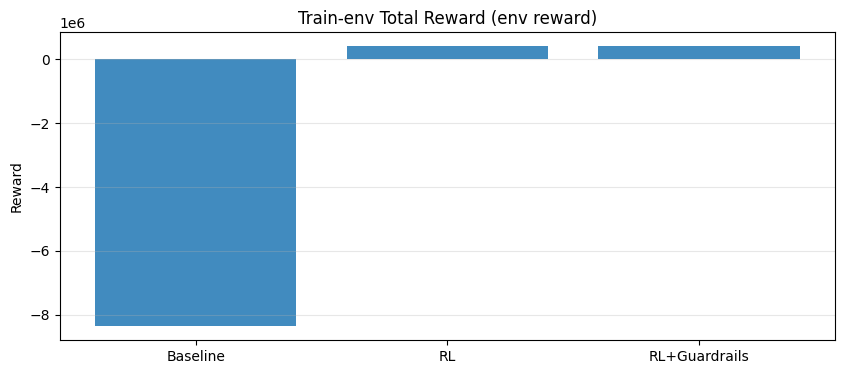

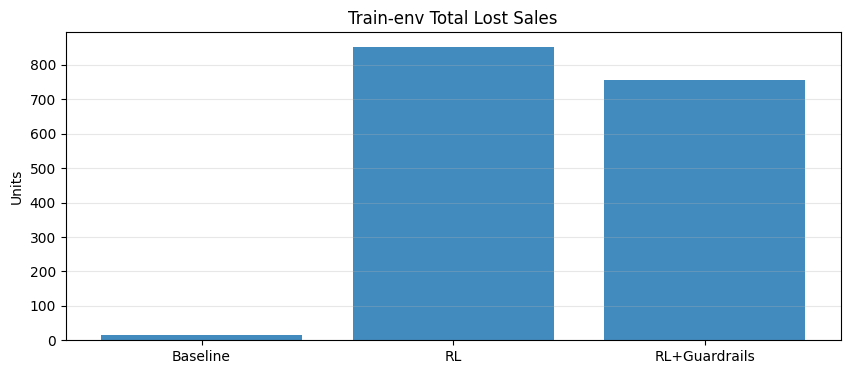

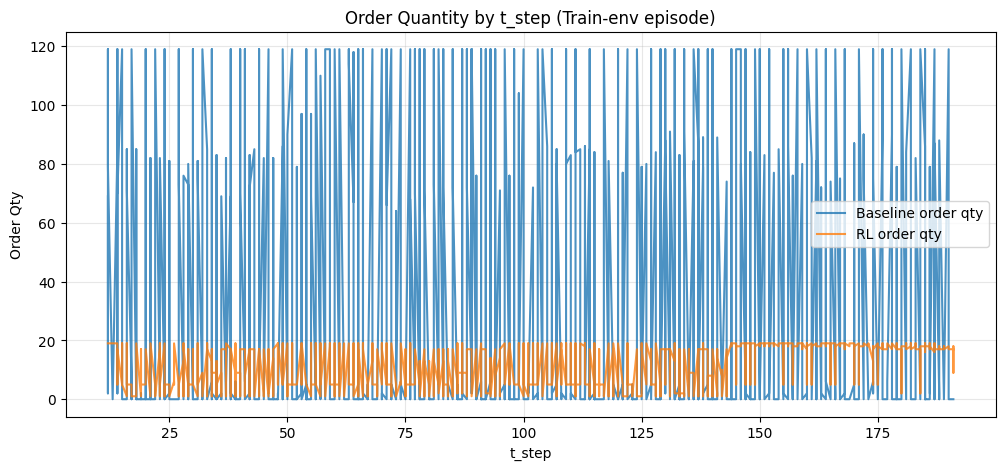

,scope,policy,steps,total_demand,total_fulfilled,fill_rate,total_lost_sales,avg_lost_sales_per_step,avg_end_on_hand,sum_reward_env,sum_reward_raw,sum_reward_clipped,avg_order_qty,sum_order_qty
0,train_env,Baseline,899,61215.843549,61201.762465,0.999770,14.081083,0.015663,49451.588522,-8.357581e+06,-8.357581e+06,-3.823668e+06,27.893215,25076.0
1,train_env,RL,899,61215.843549,60363.918414,0.986083,851.925134,0.947636,662.897626,3.987587e+05,3.987587e+05,4.096068e+05,11.281424,10142.0
2,train_env,RL_guarded,899,61215.843549,60459.918414,0.987651,755.925134,0.840851,670.489258,4.046247e+05,4.046247e+05,4.083437e+05,11.295884,10155.0
3,test_env,Baseline,179,19077.740327,18533.633496,0.971479,544.106831,3.039703,6011.734026,-7.766615e+04,-7.766615e+04,-5.060178e+04,27.413408,4907.0
4,test_env,RL,179,19077.740327,18521.409255,0.970839,556.331072,3.107995,712.712631,1.160591e+05,1.160591e+05,1.263627e+05,17.821229,3190.0
5,test_env,RL_guarded,179,19077.740327,18617.409255,0.975871,460.331072,2.571682,783.617600,1.201357e+05,1.201357e+05,1.289378e+05,17.988827,3220.0



✅ Done. All outputs saved under: rl_artifacts


In [17]:
import os
import copy
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ARTIFACT_DIR = "rl_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# -----------------------------
# Helper functions
# -----------------------------
def baseline_action_from_df(row, max_order):
    # Baseline = historical order_qty (editable)
    return int(np.clip(round(float(row.get("order_qty", 0.0))), 0, max_order - 1))

def get_deterministic_action_from_algo(algo, obs):
    module = algo.get_module("default_policy")
    batch_obs = torch.as_tensor(np.expand_dims(obs, axis=0), dtype=torch.float32)
    with torch.no_grad():
        out = module.forward_inference({"obs": batch_obs})

    if "actions" in out:
        a = out["actions"]
        action = int(a.squeeze().item()) if isinstance(a, torch.Tensor) else int(np.asarray(a).squeeze())
    elif "action_dist_inputs" in out:
        logits = out["action_dist_inputs"]
        if not isinstance(logits, torch.Tensor):
            logits = torch.as_tensor(logits, dtype=torch.float32)
        action = int(torch.argmax(logits, dim=-1).squeeze().item())
    else:
        raise KeyError(f"Unexpected output keys: {list(out.keys())}")
    return action

def run_episode_with_policy(env_cfg, policy_fn, seed=42, use_clipped_reward=True):
    cfg = copy.deepcopy(env_cfg)
    cfg["use_clipped_reward"] = bool(use_clipped_reward)
    env = SupplyChainEnv(cfg)

    obs, _ = env.reset(seed=seed)
    done = False
    rows = []
    t = 0

    while not done:
        row_data = env.data.iloc[env.current_step]
        action = int(policy_fn(obs, row_data, env))
        action = int(np.clip(action, 0, env.max_order - 1))

        next_obs, reward, terminated, truncated, info = env.step(action)

        rows.append({
            "step_idx": t,
            "t_step": int(row_data["t_step"]) if "t_step" in row_data else t,
            "month": int(row_data["month"]) if "month" in row_data else np.nan,
            "demand": float(row_data["demand"]),
            "action_order_qty": action,
            "reward_env": float(reward),
            "reward_raw": float(info["raw_reward"]),
            "reward_clipped": float(info["clipped_reward"]),
            "fulfilled": float(info["fulfilled"]),
            "lost_sales": float(info["lost_sales"]),
            "end_on_hand": float(info["end_on_hand"]),
        })

        obs = next_obs
        done = bool(terminated or truncated)
        t += 1

    return pd.DataFrame(rows)

def summarize_kpis(ep_df):
    total_demand = float(ep_df["demand"].sum())
    total_fulfilled = float(ep_df["fulfilled"].sum())
    fill_rate = (total_fulfilled / total_demand) if total_demand > 0 else np.nan

    return {
        "steps": int(len(ep_df)),
        "total_demand": total_demand,
        "total_fulfilled": total_fulfilled,
        "fill_rate": float(fill_rate),
        "total_lost_sales": float(ep_df["lost_sales"].sum()),
        "avg_lost_sales_per_step": float(ep_df["lost_sales"].mean()),
        "avg_end_on_hand": float(ep_df["end_on_hand"].mean()),
        "sum_reward_env": float(ep_df["reward_env"].sum()),
        "sum_reward_raw": float(ep_df["reward_raw"].sum()),
        "sum_reward_clipped": float(ep_df["reward_clipped"].sum()),
        "avg_order_qty": float(ep_df["action_order_qty"].mean()),
        "sum_order_qty": float(ep_df["action_order_qty"].sum()),
    }

# Policies
def rl_policy_fn(obs, row_data, env):
    return get_deterministic_action_from_algo(algo, obs)

def baseline_policy_fn(obs, row_data, env):
    return baseline_action_from_df(row_data, env.max_order)

# -----------------------------
# Step 1: Best iteration/checkpoint proxy from train rewards
# (if no checkpoints saved, choose best iteration index only)
# -----------------------------
train_rewards = np.array(rl_train_rewards, dtype=float)
best_iter_idx_1based = int(np.nanargmax(train_rewards) + 1)
best_train_reward = float(np.nanmax(train_rewards))

best_iter_info = pd.DataFrame([{
    "best_train_iter": best_iter_idx_1based,
    "best_train_reward": best_train_reward
}])

display(best_iter_info)
best_iter_info.to_csv(os.path.join(ARTIFACT_DIR, "best_iteration_info.csv"), index=False)

# -----------------------------
# Step 2 + 3: KPI comparison + decision log
# -----------------------------
use_clipped = env_config.get("use_clipped_reward", True)

rl_ep = run_episode_with_policy(env_config, rl_policy_fn, seed=SEED, use_clipped_reward=use_clipped)
bl_ep = run_episode_with_policy(env_config, baseline_policy_fn, seed=SEED, use_clipped_reward=use_clipped)

rl_kpi = summarize_kpis(rl_ep)
bl_kpi = summarize_kpis(bl_ep)

kpi_table = pd.DataFrame([
    {"policy": "Baseline", **bl_kpi},
    {"policy": "RL", **rl_kpi},
])

display(kpi_table)

improvement_table = pd.DataFrame([
    {"metric": "fill_rate", "rl_minus_baseline": rl_kpi["fill_rate"] - bl_kpi["fill_rate"]},
    {"metric": "total_lost_sales", "rl_minus_baseline": rl_kpi["total_lost_sales"] - bl_kpi["total_lost_sales"]},
    {"metric": "avg_end_on_hand", "rl_minus_baseline": rl_kpi["avg_end_on_hand"] - bl_kpi["avg_end_on_hand"]},
    {"metric": "sum_reward_env", "rl_minus_baseline": rl_kpi["sum_reward_env"] - bl_kpi["sum_reward_env"]},
    {"metric": "sum_reward_raw", "rl_minus_baseline": rl_kpi["sum_reward_raw"] - bl_kpi["sum_reward_raw"]},
    {"metric": "sum_reward_clipped", "rl_minus_baseline": rl_kpi["sum_reward_clipped"] - bl_kpi["sum_reward_clipped"]},
    {"metric": "avg_order_qty", "rl_minus_baseline": rl_kpi["avg_order_qty"] - bl_kpi["avg_order_qty"]},
])

display(improvement_table)

decision_log = rl_ep.copy()
decision_log = decision_log.rename(columns={"action_order_qty": "rl_order_qty"})
decision_log["baseline_order_qty"] = bl_ep["action_order_qty"].values
decision_log["delta_order_qty_rl_minus_baseline"] = decision_log["rl_order_qty"] - decision_log["baseline_order_qty"]
decision_log["baseline_lost_sales"] = bl_ep["lost_sales"].values
decision_log["delta_lost_sales_rl_minus_baseline"] = decision_log["lost_sales"] - decision_log["baseline_lost_sales"]
decision_log["baseline_reward_env"] = bl_ep["reward_env"].values
decision_log["delta_reward_env_rl_minus_baseline"] = decision_log["reward_env"] - decision_log["baseline_reward_env"]

display(decision_log.head(20))

# Save Step 2/3 outputs
kpi_table.to_csv(os.path.join(ARTIFACT_DIR, "kpi_comparison_train_env.csv"), index=False)
improvement_table.to_csv(os.path.join(ARTIFACT_DIR, "kpi_improvement_train_env.csv"), index=False)
decision_log.to_csv(os.path.join(ARTIFACT_DIR, "decision_log_step_by_step.csv"), index=False)

# -----------------------------
# Step 4: Guardrails
# -----------------------------
GUARDRAILS = {
    "min_order": 0,
    "max_order": env_config.get("max_order", 120) - 1,
    "lot_size": 5,
    "safety_stock_floor": 15,
    "min_order_if_below_safety": 20
}

def apply_guardrails(raw_action, env, g):
    a = int(raw_action)
    a = max(g["min_order"], min(a, g["max_order"]))
    lot = max(1, int(g["lot_size"]))
    a = int(round(a / lot) * lot)

    if env.on_hand < g["safety_stock_floor"]:
        a = max(a, g["min_order_if_below_safety"])

    a = max(g["min_order"], min(a, g["max_order"]))
    return int(a)

def rl_policy_guarded(obs, row_data, env):
    raw_a = get_deterministic_action_from_algo(algo, obs)
    return apply_guardrails(raw_a, env, GUARDRAILS)

rl_guard_ep = run_episode_with_policy(env_config, rl_policy_guarded, seed=SEED, use_clipped_reward=use_clipped)
rl_guard_kpi = summarize_kpis(rl_guard_ep)

guard_compare = pd.DataFrame([
    {"policy": "RL_raw", **rl_kpi},
    {"policy": "RL_guarded", **rl_guard_kpi},
])

display(guard_compare)

guard_compare.to_csv(os.path.join(ARTIFACT_DIR, "guardrail_comparison_train_env.csv"), index=False)
rl_guard_ep.to_csv(os.path.join(ARTIFACT_DIR, "rl_guarded_episode_train_env.csv"), index=False)

# -----------------------------
# Step 5: Out-of-sample test split
# -----------------------------
split_frac = 0.8
n = len(df)
split_idx = int(n * split_frac)

df_train = df.iloc[:split_idx].reset_index(drop=True).copy()
df_test  = df.iloc[split_idx:].reset_index(drop=True).copy()

test_env_config = copy.deepcopy(env_config)
test_env_config["data"] = df_test

rl_test_ep = run_episode_with_policy(test_env_config, rl_policy_fn, seed=SEED, use_clipped_reward=use_clipped)
bl_test_ep = run_episode_with_policy(test_env_config, baseline_policy_fn, seed=SEED, use_clipped_reward=use_clipped)
rl_guard_test_ep = run_episode_with_policy(test_env_config, rl_policy_guarded, seed=SEED, use_clipped_reward=use_clipped)

rl_test_kpi = summarize_kpis(rl_test_ep)
bl_test_kpi = summarize_kpis(bl_test_ep)
rl_guard_test_kpi = summarize_kpis(rl_guard_test_ep)

test_kpi_table = pd.DataFrame([
    {"policy": "Baseline_test", **bl_test_kpi},
    {"policy": "RL_test", **rl_test_kpi},
    {"policy": "RL_guarded_test", **rl_guard_test_kpi},
])

display(test_kpi_table)

test_kpi_table.to_csv(os.path.join(ARTIFACT_DIR, "kpi_comparison_test_env.csv"), index=False)
rl_test_ep.to_csv(os.path.join(ARTIFACT_DIR, "rl_episode_test_env.csv"), index=False)
bl_test_ep.to_csv(os.path.join(ARTIFACT_DIR, "baseline_episode_test_env.csv"), index=False)
rl_guard_test_ep.to_csv(os.path.join(ARTIFACT_DIR, "rl_guarded_episode_test_env.csv"), index=False)

# -----------------------------
# Step 6: Pilot recommendations table
# -----------------------------
N_RECOMMEND = min(20, len(df_test))
pilot_df = df_test.tail(N_RECOMMEND).reset_index(drop=True).copy()

pilot_env_config = copy.deepcopy(env_config)
pilot_env_config["data"] = pilot_df

pilot_rl_ep = run_episode_with_policy(pilot_env_config, rl_policy_fn, seed=SEED, use_clipped_reward=use_clipped)
pilot_guard_ep = run_episode_with_policy(pilot_env_config, rl_policy_guarded, seed=SEED, use_clipped_reward=use_clipped)

pilot_recommendations = pd.DataFrame({
    "t_step": pilot_rl_ep["t_step"],
    "month": pilot_rl_ep["month"],
    "demand_observed": pilot_rl_ep["demand"],
    "rl_recommended_order_qty_raw": pilot_rl_ep["action_order_qty"],
    "rl_recommended_order_qty_guarded": pilot_guard_ep["action_order_qty"],
})

display(pilot_recommendations)

pilot_recommendations.to_csv(os.path.join(ARTIFACT_DIR, "pilot_recommendations.csv"), index=False)

# -----------------------------
# Optional summary visuals
# -----------------------------
plt.figure(figsize=(10,4))
plt.bar(["Baseline", "RL", "RL+Guardrails"], [
    bl_kpi["sum_reward_env"], rl_kpi["sum_reward_env"], rl_guard_kpi["sum_reward_env"]
], alpha=0.85)
plt.title("Train-env Total Reward (env reward)")
plt.ylabel("Reward")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.bar(["Baseline", "RL", "RL+Guardrails"], [
    bl_kpi["total_lost_sales"], rl_kpi["total_lost_sales"], rl_guard_kpi["total_lost_sales"]
], alpha=0.85)
plt.title("Train-env Total Lost Sales")
plt.ylabel("Units")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(decision_log["t_step"], decision_log["baseline_order_qty"], label="Baseline order qty", alpha=0.8)
plt.plot(decision_log["t_step"], decision_log["rl_order_qty"], label="RL order qty", alpha=0.8)
plt.title("Order Quantity by t_step (Train-env episode)")
plt.xlabel("t_step")
plt.ylabel("Order Qty")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# Final compact report
# -----------------------------
final_report = pd.DataFrame([
    {
        "scope": "train_env",
        "policy": "Baseline",
        **bl_kpi
    },
    {
        "scope": "train_env",
        "policy": "RL",
        **rl_kpi
    },
    {
        "scope": "train_env",
        "policy": "RL_guarded",
        **rl_guard_kpi
    },
    {
        "scope": "test_env",
        "policy": "Baseline",
        **bl_test_kpi
    },
    {
        "scope": "test_env",
        "policy": "RL",
        **rl_test_kpi
    },
    {
        "scope": "test_env",
        "policy": "RL_guarded",
        **rl_guard_test_kpi
    },
])

display(final_report)
final_report.to_csv(os.path.join(ARTIFACT_DIR, "final_report.csv"), index=False)

print(f"\n✅ Done. All outputs saved under: {ARTIFACT_DIR}")

In [18]:
from pathlib import Path

checkpoint_dir = Path("rl_artifacts/policy_checkpoint").resolve()

algo.save(str(checkpoint_dir))

TrainingResult(checkpoint=Checkpoint(filesystem=local, path=D:\github\Grad.app\rl_artifacts\policy_checkpoint), metrics={'timers': {'training_iteration': 7.3194429999985005, 'restore_env_runners': 8.19999877421651e-06, 'training_step': 7.319268000001102, 'env_runner_sampling_timer': 5.22515039999962, 'learner_update_timer': 2.087867299998834, 'synch_weights': 0.0025140999987343093, 'synch_env_connectors': 0.001949100000274484}, 'env_runners': {'module_to_env_connector': {'timers': {'connectors': {'remove_single_ts_time_rank_from_batch': np.float64(2.5232922122049504e-06), 'tensor_to_numpy': np.float64(6.824290767456106e-05), 'get_actions': np.float64(0.00022376263934754294), 'un_batch_to_individual_items': np.float64(2.2921034717255295e-05), 'listify_data_for_vector_env': np.float64(3.650045565715604e-05), 'normalize_and_clip_actions': np.float64(2.901727062100405e-05)}}, 'connector_pipeline_timer': np.float64(0.000517311685076946)}, 'num_episodes_lifetime': 4556.0, 'num_episodes': np.

In [19]:
print(final_report[
    ["policy",
     "sum_reward_env",
     "sum_reward_raw",
     "sum_reward_clipped"]
])

       policy  sum_reward_env  sum_reward_raw  sum_reward_clipped
0    Baseline   -8.357581e+06   -8.357581e+06       -3.823668e+06
1          RL    3.987587e+05    3.987587e+05        4.096068e+05
2  RL_guarded    4.046247e+05    4.046247e+05        4.083437e+05
3    Baseline   -7.766615e+04   -7.766615e+04       -5.060178e+04
4          RL    1.160591e+05    1.160591e+05        1.263627e+05
5  RL_guarded    1.201357e+05    1.201357e+05        1.289378e+05
